In [1]:
import nibabel as nib
import torch, torchvision
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.optim.lr_scheduler import StepLR
import os
from PIL import Image
from torchvision.transforms import Resize, Compose, ToTensor, Normalize
import numpy as np
import skimage
import matplotlib.pyplot as plt
import time
from tqdm import tqdm
from sklearn.metrics import mean_squared_error
from monai.losses.dice import *  # NOQA
from monai.losses.dice import DiceLoss, DiceCELoss
from IPython.display import clear_output
from monai import metrics
import tempfile, os
import monai
from monai.losses import DiceLoss, DiceCELoss, SoftclDiceLoss, DiceFocalLoss, NACLLoss
from torch.nn import KLDivLoss
import kornia
import os
import random
from torchmetrics.functional.image import image_gradients
from kornia.losses import total_variation
from Models.models import Siren, Finer
from Utils.plotting_utils import plot_2_images, plot_4_images, plot_5_images, loss_plot, plot_results_after_train
from Utils.utils import  gradient, laplace, get_device,  get_metrics, get_quant_results, get_quant_results2

from Utils.utils import get_full_img, norm, dice_stack_helper
# from Experiments.Experiment_1 import train, load_data, default_config, get_full_img, get_gt_seg, priors, lf_segmentations, norm



from Models.model_trainer2D import ModelTrainer
from Utils.defaults import default_config

from torch.utils.tensorboard import SummaryWriter
import warnings
warnings.filterwarnings("ignore")
from Utils.plotting_utils2 import plot_seg_results_paper, plot_final_results_paper, plot_hf_results_paper, plot_final_results_compare_paper, plot_seg_results_compare_2_paper
from Utils.plotting_utils import loss_plot, plot_image_metrics, plot_4_images



import copy




from torch.utils.data import DataLoader, Dataset
import nibabel as nib
from Utils.utils import dice_stack_helper
from Utils.defaults import default_config

from Utils.utils import get_device, norm
import sys
from PIL import Image
from Data.load_data_3d import load_data, get_gt_seg
from onnxruntime import InferenceSession
import onnx
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

# random.seed(9600) #For Reproducibility

In [7]:
def final_inference(config, model_loc, trainer):
    # model_loc = "./sashimi/models/best_model_v0.onnx"
    onnx_model = onnx.load(model_loc)
    onnx.checker.check_model(onnx_model)
    sess = InferenceSession(onnx_model.SerializeToString())
    model_output_seg_pre, model_output_seg, model_output_img_pre, model_output_img, coords = sess.run(None, {"onnx::MatMul_0" : trainer.coord_chunk.detach().cpu().numpy()})
    model_output_seg_pre, model_output_seg, model_output_img_pre, model_output_img, coords = torch.from_numpy(model_output_seg_pre), torch.from_numpy(model_output_seg), torch.from_numpy(model_output_img_pre), torch.from_numpy(model_output_img), torch.from_numpy(coords)
    hf_pred = norm(get_full_img(model_output_seg, model_output_img, config)) #final HF pred
    cnr_mod = ContrastModulation()
    lf_pred = cnr_mod.forward(model_output_seg, model_output_img, config["M"])
    
    seg_pred = model_output_seg #segmentation only
    img_pred = model_output_img #intensities only
    return hf_pred, lf_pred, seg_pred, img_pred

In [5]:
hf_ground_truth, lf_gt, prior_seg_dice, lf_gt_seg_dice, M = load_data(1, config) #uncomment

Device =  mps
torch.Size([87, 96, 192])
BG Noise in different regions : 4.7445857300717 4.415978248235479 4.956849146645869 4.8247938816077935
known_m =  [0.75 0.9  0.9 ]
[[ 28.84998854   0.          -7.89492106]
 [ 28.84998854 -22.35619149   0.        ]
 [  0.          22.35619149  -7.89492106]] [14.53206245  1.51691906 13.01514339]
             m_init  epsilon  \
0   [0.1, 0.1, 0.1]     0.00   
1   [0.1, 0.1, 0.1]     0.01   
2   [0.1, 0.1, 0.1]     0.05   
3   [0.1, 0.1, 0.1]     0.10   
4   [0.1, 0.1, 0.1]     0.20   
..              ...      ...   
59  [0.5, 0.5, 0.5]     0.10   
60  [0.5, 0.5, 0.5]     0.20   
61  [0.5, 0.5, 0.5]     0.30   
62  [0.5, 0.5, 0.5]     0.40   
63  [0.5, 0.5, 0.5]     0.50   

                                                 loss  \
0   [144.631340676391, 144.63133495698293, 144.631...   
1   [144.63164067639102, 144.63163495701272, 144.6...   
2   [144.632840676391, 144.63283495713193, 144.632...   
3   [144.634340676391, 144.63433495728094, 144.634.

In [98]:
hf_ground_truth.shape, prior_seg_dice.shape

((174, 192, 192), torch.Size([1, 4, 174, 192, 192]))

In [137]:
from test3D import ModelTrainer
config = default_config
model_loc = "/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Hulf_Synth/saved_models/model_supervised.onnx"
mt = ModelTrainer(config, lf_gt, prior_seg_dice, lf_gt_seg_dice, M)
# hf_pred, lf_pred, seg_pred, img_pred = final_inference(config, model_loc, mt)

Device =  mps
Features =  3
init complete mt


In [138]:
onnx_model = onnx.load(model_loc)
onnx.checker.check_model(onnx_model)

onnx_model.graph.input[0].type.tensor_type.shape.dim[1].ClearField('dim_value')
# onnx_model.graph.input[0].type.tensor_type.shape.dim[2].ClearField('dim_value')
# onnx_model.graph.input[0].type.tensor_type.shape.dim[3].ClearField('dim_value')
sess = InferenceSession(onnx_model.SerializeToString())

In [139]:
onnx_model.graph.input[0].type.tensor_type.shape

dim {
  dim_value: 1
}
dim {
}
dim {
  dim_value: 3
}

In [140]:
# sess.run(None, {"onnx::MatMul_0" : trainer.coord_chunk.detach().cpu().numpy()})
from test3D import define_coords, visualize_volume_slices
grid_size = (192, 172, 192)
# grid_size = (48, 24, 22)
grid = define_coords(grid_size)
model_output_seg_pre, model_output_seg, model_output_img_pre , model_output_img, coords = sess.run(None, {"onnx::MatMul_0" : grid.reshape(-1, 3).unsqueeze(0).numpy()})
# model_output_seg_pre, model_output_seg, model_output_img_pre , model_output_img, coords = sess.run(None, grid.reshape(-1, 3).unsqueeze(0).numpy())

2025-08-11 19:37:57.474372 [W:onnxruntime:, execution_frame.cc:876 VerifyOutputSizes] Expected shape from model of {1,101376,3} does not match actual shape of {1,6340608,3} for output 45
2025-08-11 19:38:58.707192 [W:onnxruntime:, execution_frame.cc:876 VerifyOutputSizes] Expected shape from model of {1,101376,4} does not match actual shape of {1,6340608,4} for output input.3
2025-08-11 19:38:58.750797 [W:onnxruntime:, execution_frame.cc:876 VerifyOutputSizes] Expected shape from model of {1,101376,4} does not match actual shape of {1,6340608,4} for output 44
2025-08-11 19:38:59.251400 [W:onnxruntime:, execution_frame.cc:876 VerifyOutputSizes] Expected shape from model of {1,101376,4} does not match actual shape of {1,6340608,4} for output input
2025-08-11 19:38:59.318022 [W:onnxruntime:, execution_frame.cc:876 VerifyOutputSizes] Expected shape from model of {1,101376,4} does not match actual shape of {1,6340608,4} for output 40


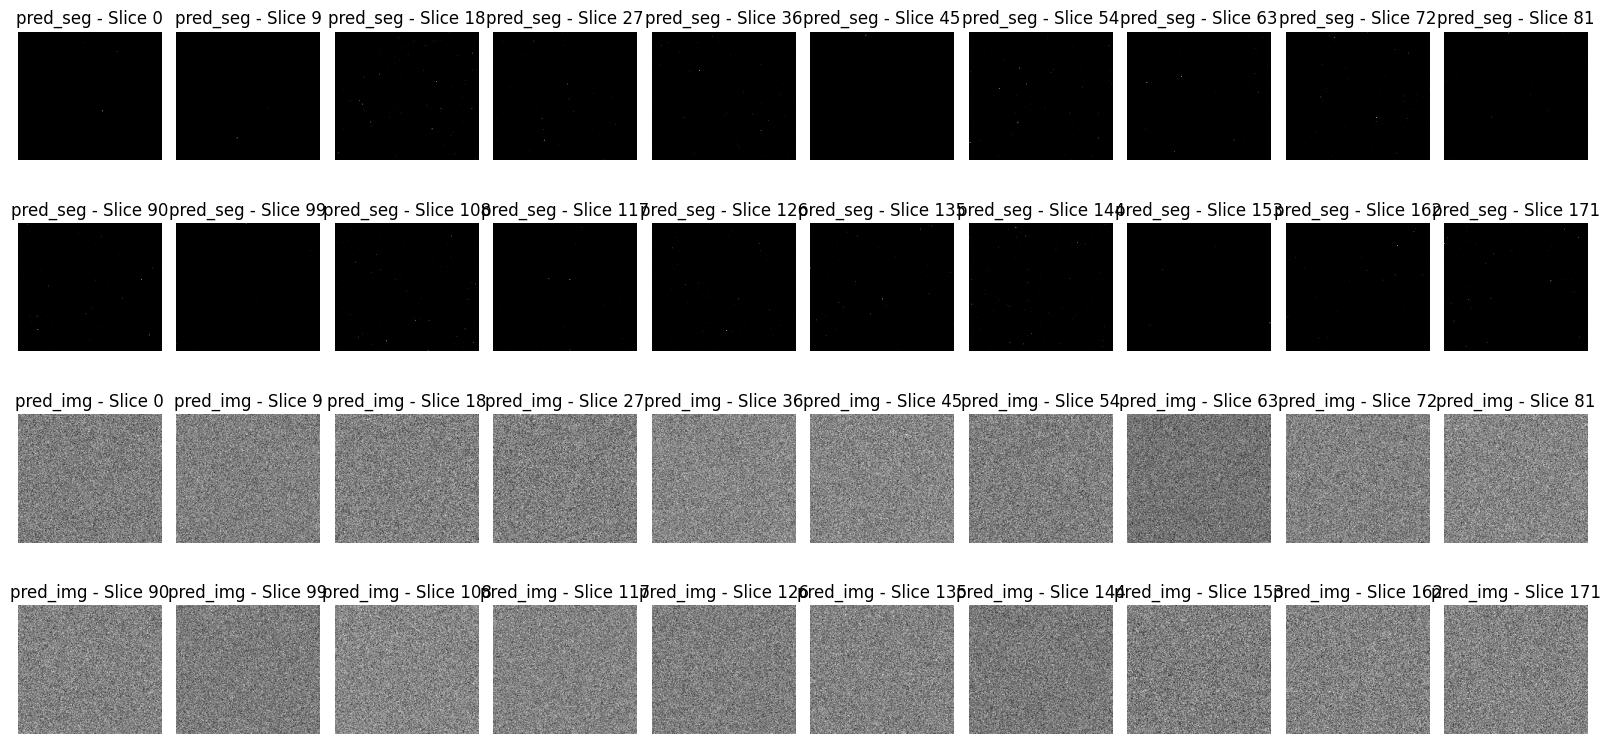

In [141]:
from test3D import define_coords, visualize_volume_slices
fig = visualize_volume_slices(torch.from_numpy(model_output_seg[0,:,1].reshape(grid_size)), torch.from_numpy(model_output_img[0,:,1].reshape(grid_size)), axis=0, num_slices=20, title1='pred_seg', title2='pred_img')

In [142]:
import nibabel as nib
seg0_nifti = nib.Nifti1Image(model_output_seg[0,:,0].reshape(grid_size), np.eye(4))
seg1_nifti = nib.Nifti1Image(model_output_seg[0,:,1].reshape(grid_size), np.eye(4))
seg2_nifti = nib.Nifti1Image(model_output_seg[0,:,2].reshape(grid_size), np.eye(4))
seg3_nifti = nib.Nifti1Image(model_output_seg[0,:,3].reshape(grid_size), np.eye(4))
nib.save(seg0_nifti, './results/seg0_nifti.nii.gz')
nib.save(seg1_nifti, './results/seg1_nifti.nii.gz')
nib.save(seg2_nifti, './results/seg2_nifti.nii.gz')
nib.save(seg3_nifti, './results/seg3_nifti.nii.gz')

In [143]:
img0_nifti = nib.Nifti1Image(model_output_img[0,:,0].reshape(grid_size), np.eye(4))
img1_nifti = nib.Nifti1Image(model_output_img[0,:,1].reshape(grid_size), np.eye(4))
img2_nifti = nib.Nifti1Image(model_output_img[0,:,2].reshape(grid_size), np.eye(4))
img3_nifti = nib.Nifti1Image(model_output_img[0,:,3].reshape(grid_size), np.eye(4))
nib.save(img0_nifti, './results/img0_nifti.nii.gz')
nib.save(img1_nifti, './results/img1_nifti.nii.gz')
nib.save(img2_nifti, './results/img2_nifti.nii.gz')
nib.save(img3_nifti, './results/img3_nifti.nii.gz')

In [144]:
final_img = (model_output_seg[0,:,0] * model_output_img[0,:,0]) + (model_output_seg[0,:,1] * model_output_img[0,:,1]) + (model_output_seg[0,:,2] * model_output_img[0,:,2]) + (model_output_seg[0,:,3] * model_output_img[0,:,3])
final_img = nib.Nifti1Image(final_img.reshape(grid_size), np.eye(4))
nib.save(final_img, './results/final_img.nii.gz')